<img style="float: center;" src='https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_header.png' alt="stsci_logo" width="900px"/>

# Exoplanet Time-Series Observations with MIRI
## From Pixels to Transit/Eclipse Light Curves to Results
### MIRI/LRS Notebook #2

**Authors**: Taylor James Bell (ESA/AURA for STScI)<br>
**Last Updated**: May 2, 2025<br>
**Pipeline Version**: 1.18.0 (Build 11.3)

**Purpose**:<br/>

It should not be necessary to edit any cells other than in the [Configuration](#1.-Configuration) section unless you want to manually explore/optimize different data processing steps.

**Data**:<br/>
This notebook is set up to use an example dataset is from [Program ID](https://www.stsci.edu/jwst/science-execution/program-information) 1366 (PI: Batalha, Natalie) which is the JWST Transiting Exoplanet Community ERS program.

**JWST pipeline version and CRDS context**:<br/>
This notebook was written for the calibration pipeline version given above and uses the context associated with this version of the JWST Calibration Pipeline. Information about this and other contexts can be found in the JWST Calibration Reference Data System (CRDS) [server]((https://jwst-crds.stsci.edu/)). If you use different pipeline
versions, please refer to the table [here](https://jwst-crds.stsci.edu/display_build_contexts/) to determine what context to use. To learn more about the differences for the pipeline, read the relevant [documentation](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline/jwst-operations-pipeline-build-information)

**Preparation**:<br/>
The installation instructions and data download instructions are specified in the Setup.ipynb notebook

<hr style="border:1px solid gray"> </hr>

## Table of Contents

* [0. Configuration](#0.-Configuration)
* [5. Sampling white lightcurve posterior](#5.-Sampling-white-lightcurve-posterior)

<hr style="border:1px solid gray"> </hr>

## 0. Configuration

The first step is to setup the notebook and environment.

We'll first import Eureka! along with some other useful packages.

In [1]:
import eureka
import os
import numpy as np

Could not import catwoman. Functionality may be limited.


Next, we will re-use the eventlabel from Notebook #1. The eventlabel is a short, meaningful label (without spaces) that describes the data you're currently working on. For simplicity, simply set `eventlabel = 'miri_lrs'`. This same event label should be used throughout all stages.

In [2]:
eventlabel = 'miri_lrs'

Please adjust the following variable to specify specify where you downloaded the data in the Setup.ipynb notebook!

In [3]:
path_to_data_folder_on_your_machine = '~/Data/JWST/jwebbinar41/miri_lrs/'
path_to_data_folder_on_your_machine = os.path.expanduser(path_to_data_folder_on_your_machine)

<hr style="border:1px solid gray"> </hr>

### An introduction to Bayesian statistics

*The text discussing Bayesian statistics throughout this notebook is adapted from:*
<blockquote>Bell, Taylor James. "Characterizing Ultra-Hot Jupiters through Theoretical Modelling and Precise Observations." Doctoral Thesis, McGill University, 2021.</blockquote>

<br/>

**This introduction to Bayesian statistics can be skipped if you are already familiar, and you can resume at "Optimizing a fit to the white lightcurve".**

<br/>

This workshop will make heavy use of Bayesian statistics which is a fundamental aspect of most aspects of modern science and data analysis. According to Bayes' theorem, the probability, $P$, of a hypothesis, $H$, given a set of observations, $\mathbf{X}$, and a collection of prior knowledge, $I$, is given by
\begin{equation*}
    P(H|\mathbf{X},I) = \frac{P(\mathbf{X}|H,I) P(H|I)}{P(\mathbf{X}|I)},
\end{equation*}
where $|$ reads as "given" (that all terms to the right are assumed true), and the comma reads as "and". The power of Bayes' theorem is that it allows us to compute the *posterior probability*, $P(H|\mathbf{X},I)$, using the much more easily calculable *likelihood function*, $P(\mathbf{X}|H,I)$, which is the probability that we would have observed the data $\mathbf{X}$ if the hypothesis and prior knowledge were correct. The $P(H|I)$ term is the *prior probability* and summarizes how our prior knowledge affects our hypothesis before having measured the data $\mathbf{X}$. Finally, the $P(\mathbf{X}|I)$ term is the *evidence* or *marginal likelihood* and is often omitted when fitting a model to data as it is only a normalization term and does not depend on the hypothesis.

When fitting a set of observations, a hypothesis typically consists of a function describing the model which depends on a collection of parameters, $\theta$, and hyperparameters, $\alpha$. Bayes' theorem can then be re-written as
\begin{equation*}
    P(\theta|\mathbf{X},\alpha) \propto P(\mathbf{X}|\theta,\alpha) P(\theta|\alpha).
\end{equation*}
Fitting the observations usually starts by freezing the set of hyperparameters and then evaluating the posterior probability by comparing different model predictions to the observed data. Fitting the observations then requires determining the values of $\theta$ that maximize the posterior probability (called the Maximum A Posteriori estimate or MAP estimate), while determining the uncertainty on the model parameters involves determining the range of values of $\theta$ that provide an adequately good fit to the observations (called the confidence interval).

In principle, one could simultaneously estimate the optimal value of $\theta$ and its confidence interval from the posterior probability density function (PDF) by calculating the posterior probability for all values of $\theta$; this is called a grid search. While this technique may be feasible for discrete parameters or low dimensional problems, performing a grid search when the vector $\theta$ contains tens or thousands of continuous variables becomes immensely challenging and computationally inefficient. Instead, various algorithms can be used to compute the MAP estimate and the confidence interval, some of which we will make use of in this workshop.

<hr style="border:1px solid gray"> </hr>

## 5. Sampling white lightcurve posterior

A sampling algorithm like the Markov Chain Monte-Carlo (MCMC) method is typically used to estimate parameter best-fit values and uncertainties. Monte-Carlo (MC) methods in general involve randomly sampling values of $\theta$, while MCMCs are a specific variant where samples are randomly drawn based on the knowledge of the posterior probability from the previously drawn value; the draws of MCMC are typically called steps taken by a walker, and a collection of many walker steps are called a chain.

One increasingly popular sampling algorithm is called [Nested Sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm) which does not necessarily use an MCMC method. Nested sampling can be difficult to explain intuitively, but one of the nice advantages to nested sampling is that it can be used for model comparison. More relevant to our purposes here, the [dynesty](https://dynesty.readthedocs.io/en/stable/) dynamic nested sampling algorithm is able to quickly sample our posterior and has a convenient stopping condition which ensures the sampler has converged so that we get reliable uncertainties.

### 5.1 Setting the Stage 5 "Eureka! Control File" (ECF)

**This determines what will happen during Stage 5**

The most important parameters and their recommended settings are described below, but more context can be found on the [Eureka! documentation website](https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-5).

1. Set `ncpu` to the number of CPU threads you want to use. If set to `1` no multiprocessing will be done, and this parameter can be increased to ~2x your CPU core count for faster runs.
3. Set `verbose` to `True` so you get lots of useful information printed out.
4. Set `fit_method` to `[dynesty]` to instead use the dynesty sampler.
5. Set `run_myfuncs` to `[batman_ecl, polynomial, expramp, ypos, ywidth]`. Each element in this list is a function that will be fitted to the data — we'll setup more aspects of each function below when we setup the "Eureka! Parameter File". The `batman_ecl` function uses the [batman](http://lkreidberg.github.io/batman/docs/html/index.html) package to model an eclipse function which describes how the astrophysical flux decreases when we go from seeing the combined light from the star and planet to just the light from the star when the planet is behind the star. The `polynomial` function allows us to fit for systematic trends in time (like a linear slope) as well as fitting for the overall baseline flux level; you must always use a `polynomial` model when fitting observations to at least model the baseline flux level. The `expramp` function allows us to model the detector systematic ramp in MIRI data caused by some combination of detector persistence/settling. The `ypos` and `ywidth` functions model changes in the flux caused by changes in the position and PSF width of the spectrum on the detector in the spatial direction; we computed these during Stage 3 in Workshop #1. JWST is quite stable over time, so these functions just assume that the flux is linearly correlated with the spatial position and PSF width. Not all observations require that you use the `ypos` and `ywidth` functions, but they're often useful for MIRI observations.
6. Set `fit_par` to `./S5_fit_par_template.epf`. This tells Eureka! where you have specified the priors and initial guesses for the parameters the control the functions listed above.
7. Set `manual_clip` to `[[None,975]]` to remove **a lot** of the initial integrations which are worst affected by the initial exponential ramp. You **do not** always remove this many integrations, but we will for this demonstration for multiple reasons.
8. Leave all parameters under the "Limb darkening controls" heading at their default values of `None` since we're fitting an eclipse observation and stellar limb darkening has no impact on eclipse observations.
9. Add the following dynesty-related settings
  1. Set `run_nlive` to `'min'`. This sets the number of "live" points that dynesty will use (for more details see [here](https://dynesty.readthedocs.io/en/stable/faq.html#live-point-questions)). For reliable results, this must be greater than `ndim * (ndim + 1) // 2`, where `ndim` is the number of fitted parameters and `//` indicates integer division. In general, the larger this number the more robust your results will be and the longer they will take to run. A value of `'min'` will make sure the minimum number of live points is respected and is often sufficient for initial analyses, while more in-depth analyses might benefit from using a larger number of live points.
  2. Set `run_bound` to `'multi'`. This sets the type of bounds used by dynesty to "multiple ellipsoid decomposition". For more information, see [here](https://dynesty.readthedocs.io/en/stable/faq.html#bounding-questions). A value of `'multi'` should work for most problems.
  3. Set `run_sample` to `'rwalk'`. This is often the optimal sampling method but that sometimes depends on the number of fitted parameters, and `auto` can sometimes also be a safe bet for most problems. For more information, see [here](https://dynesty.readthedocs.io/en/stable/faq.html#sampling-questions).
  4. Finally, set `run_tol` to `0.1`. This determines the stopping condition of the sampler. Smaller values will result in more precise posteriors at the cost of increased runtime, while larger values can result in poorly converged garbage. In general, a value of `0.1` should work for initial investigations, while `0.01` might work better when producing your "final" results.
10. Set `isplots_S5` to `5` so that you see lots of useful plots that can help you debug your fits.
11. Set `nbin_plot` to `None` since we're not fitting that many integrations and we don't really need to temporally bin the data when plotting to be able to see our astrophysical signal.
12. Set `hide_plots` to `False` so that all your figures appear within the notebook (you can set this to `True` if you're running the code from the terminal and want to avoid an excessive number of pop-ups appearing).
13. Set `topdir` to the folder containing your input "white" Stage 4 folder.
14. Since we're fitting white lightcurves, we'll adjust the `inputdir` to `Stage4_white/S4_2025-05-01_miri_lrs_run1` and the `outputdir` to `Stage5_white`. This `inputdir` setting will use our provided Stage 4 output files, but if you want to try using your own results from Workshop #1, you can instead set `intputdir` to `Stage4_white` to use your most recent Stage4_white result or you can choose a specific run using the syntax `Stage4_white/S4_YYYY-MM-DD_miri_lrs_runN` where YYYY is the year (e.g., `2025`), MM is the month (e.g., `04`), DD is the day (e.g., `18`), and N is the particular run number that you want to use (e.g., `1`).

In [4]:
s5_ecf_contents = f"""
# Eureka! Control File for Stage 5: Lightcurve Fitting

ncpu             16       # The number of CPU threads to use when running emcee, dynesty, or pymc3 in parallel

allapers         False    # Run S5 on all of the apertures considered in S4? Otherwise will use newest output in the inputdir

# NORMAL FITTING
fit_method       [dynesty]    # Which fitting methods do you want to use? This can be a list if you want to run multiple fitters (e.g. an optimizer and then a sampler that will start from the optimizer's final position).
run_myfuncs      [batman_ecl, polynomial, expramp, ypos, ywidth]    # What functions do you want to fit?
fit_par          ./S5_fit_par_template.epf  # DO NOT CHANGE THIS LINE (it has been specially set for this workshop)

# Manual clipping in time
manual_clip      [[None,975]] # A list of lists specifying the start and end integration numbers for manual removal.

# Dynesty Settings
run_nlive       'min'    # Must be > ndim * (ndim + 1) // 2
run_bound       'multi'
run_sample      'rwalk'
run_tol         0.1

# Plotting controls
interp           False   # Should astrophysical model be interpolated (useful for uneven sampling like that from HST)

# Diagnostics
isplots_S5       5       # Generate few (1), some (3), or many (5) figures (Options: 1 - 5)
nbin_plot        None    # The number of bins that should be used for figures 5104 and 5304. Defaults to 100.
hide_plots       False   # If True, plots will automatically be closed rather than popping up
verbose          True    # If True, more details will be printed about steps

# Project directory
topdir           {path_to_data_folder_on_your_machine}

# Directories relative to project dir
inputdir         Stage4_white/S4_2025-05-01_miri_lrs_run1
outputdir        Stage5_white
"""

with open(f'S5_{eventlabel}.ecf', 'w') as f:
    f.write(s5_ecf_contents)

### 5.2 Setting the Stage 5 "Eureka! Parameter File" (EPF)

**This determines the priors and starting guesses for your fitted models**

Here is where we dive further into specifying details about the models that we want to fit to our data. We'll discuss the ones relevant to this fit below, but more details can be found on the [Eureka documentation webpage](https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-5-fit-parameters).

Each row has 6 columns:
> `Name Value Free? PriorPar1 PriorPar2 PriorType`

`Name` specifies the name of a fitted variable. These have to be from a very specific list of options so that Eureka! knows what the variable is supposed to mean. For example `rp` is the planet-to-star radius ratio (so `rp` squared would be equal to the transit depth) and `fp` is the eclipse depth.

`Value` specifies the starting guess for the variable. This column is used for all optimization or sampling algorithms except dynesty which does not take a starting guess. In general, starting guesses do not need to be exceptionally good, and as long as they're in the vague ballpark then the fitting or sampling algorithm should work fine. For fixed parameters (see the description of `Free?` below), this column sets the value of the parameter.

`Free?` specifies whether the parameter should be freely fitted for each wavelength (`'free'`), should be set to a fixed value and not changed throughout the fit (`'fixed'`), is an auxilliary variable that also should not be fit (`'independent'`). Other more advanced options also exist, but we won't cover them here. For fixed and independent variables, the remaining three columns are not used.

**The rightmost column**, `PriorType`, determines what type of prior function you will use to constrain your fitted parameters. The three options are Normal (`N`; also known as a Gaussian prior), Uniform (`U`), and Log-Uniform (`LU`). Some sampling algorithms work faster or more efficiently with Normal priors, but sometimes you must use Uniform priors to avoid unphysical parameter settings. Normal priors are typically best for orbital parameters for which there are published best-fit values and uncertainties.

The meanings of the `PriorPar1` and `PriorPar2` columns are dependent on the setting of the `PriorType` column (which is the last column). If `PriorType` is N, then `PriorPar1` is the mean of the Gaussian prior and `PriorPar2` is the standard deviation. If `PriorType` is U, then `PriorPar1` is the lower limit of the parameter and `PriorPar2` is the upper limit of the parameter. If `PriorType` is LU, then `PriorPar1` is the lower limit of the log of the parameter, and `PriorPar2` is the upper limit of the log of the parameter.


<br/>

---

<br/>


For your fit, you will need the following variables:

- For `per` (planetary orbital period), `t0` (time of conjunction; also called linear ephemeris or transit midpoint), `inc` (planetary orbital inclination), `a` (planetary orbital semi-major axis), `ecc` (planetary orbital eccentricity), and `w` (planetary orbital argument of periastron) we will make use of previously published research. In general, one can navigate to the [NASA Exoplanet Archive's page](https://exoplanetarchive.ipac.caltech.edu/overview/WASP-43b) about our target WASP-43b and click on "WASP-43 b Planetary Parameters". However, since these MIRI/LRS data were already published and give more accurate orbital parameters, we will use the values published by [Hammond et al. 2024](https://ui.adsabs.harvard.edu/abs/2024AJ....168....4H/abstract) (Table 1, "Eclipse Map Fit") as priors. Where there are two values for the uncertainty, just use the larger of the two. Also, while the published `t0` is in units of BJD_TDB, JWST timestamps are in units of B**M**JD_TDB, where the M means "modified" and BMJD_TDB=BJD_TDB-2400000.5; this removes the first two digits that won't change in our lifetime and changes the time so that a new BMJD_TDB day starts at midnight (while new BJD_TDB days inconventiently start at noon). In general we would need to subtract that 2400000.5 from the published `t0` value when entering it into your EPF, but [Hammond et al. 2024](https://ui.adsabs.harvard.edu/abs/2024AJ....168....4H/abstract) published the `t0` in units of BMJD_TDB already. [Hammond et al. 2024](https://arxiv.org/abs/2404.16488) did not re-fit the orbital period, `per`, and instead just fixed the orbital period to `0.813474056` days from [Kokori et al. 2023](https://ui.adsabs.harvard.edu/abs/2023ApJS..265....4K/abstract); we will do the same. And since the planet is consistent with a zero-eccentricity orbit, let's set `ecc` to be `'fixed'` to `0` and arbitrarily set `w` to be `'fixed'` to `90` (the value of `w` doesn't matter if the eccentricity is zero). Additionally, with only a single eclipse we will likely be unable to significantly improve the constraints on any of these orbital parameters with the exception of the mid-eclipse time, so we will set all these orbital parameters except `t0` to be `'fixed'` to their published values.
- In summary, you should have:
> `per 0.813474056 'fixed'`<br/>
> `t0 55934.292283 'free' 55934.292283 0.000011 N`<br/>
> `inc 82.106 'fixed'`<br/>
> `a 4.859 'fixed'`<br/>
> `ecc 0 'fixed'`<br/>
> `w 90 'fixed'`<br/>

- For `Rs` (the stellar radius in units of Solar radii), we can again use the [NASA Exoplanet Archive's page](https://exoplanetarchive.ipac.caltech.edu/overview/WASP-43b) about WASP-43, this time instead clicking on the "WASP-43 Stellar Parameters" section. This parameter is only used to account for the finite speed of light, so simply fixing it to the published value from Bonomo et al. 2017 will work:
> `Rs 0.667 'fixed'`

- For `rp` (planet-to-star radius ratio), we'll use the radius fitted from a later part of these data where the planet transited. Please set `rp` to be fixed to a value of 0.15839 based on the results of [Hammond et al. 2024](https://ui.adsabs.harvard.edu/abs/2024AJ....168....4H/abstract) (Table 1, "Eclipse Map Fit"). Without this knowledge, one could also compute the planet-to-star radius ratio from the planet and star radii published by Bonomo et al. 2017, although care would need to be taken to ensure units were properly accounted for. In summary, set:
> `rp 0.15839 'fixed'`

- Leave time_offset at it's default settings of:
> `time_offset 0 'independent'`.

- For `fp` (eclipse depth) we will have to create a "minimally informative prior". With this prior, we seek to constrain the model to the very rough area that we expect for the parameters while minimally influencing the final results with our semi-arbitrary decision. For `fp`, a visual inspection of the lightcurve produced in the last notebook suggests that the eclipse depth is around 6000 ppm, so a reasonable, "minimally informative" prior could be $6000 \pm 5000$ ppm which would be specified as:
  > `fp 6000e-6 'free' 6000e-6 5000e-6 N`

  where `6000e-6` is a more conventient way of specifying 6000 ppm than carefully counting decimal places and specifying `0.006` (although both options are possible).

- Our systematics models are controlled by
  - `c0` (the baseline flux level) and `c1` (which fits for a linear slope as a function of time). These two parameters control the `polynomial` function we specified in the ECF settings above. To make things easier, Eureka! normalizes the lightcurves by the median flux, so the value of `c0` should be approximately 1, but more precisely should be set to the value of the normalized flux during the middle of the eclipse observation; by eye this appears to be around 0.996. The value of `c1` is in the units of change in `c0` per day, and is typically very small (the absolute value of `c1` is typically at or below 0.001. Reasonable, minimally informative priors could then be:
  > `c0 0.996 'free' 0.996 0.01 N`<br/>
  > `c1 0 'free' 0 0.01 N`
  - `r0` (the exponential ramp amplitude) and `r1` (the exponential ramp timescale). These two parameters control the `expramp` function we specified in the ECF settings above. The value of `r0` controls the amplitude of the exponential ramp and should be close to 0 given how many initial integrations we have trimmed. The value of `r1` is the exponential decay rate in units of days<sup>-1</sup>, and is typically in the range of 5-500. Reasonable, minimally informative priors could then be:
  > `r0 0 'free' 0 0.01 N`<br/>
  > `r1 200 'free' 5 500 U`
  - `ypos` which assumes the observed flux varies linearly with the position on the detector. This can happen because of flux lost outside of our extraction aperture or between gaps between pixels. Values for `ypos` are typically well below 1, so a reasonable, minimally informative prior could then be:
  > `ypos 0 'free' 0 0.1 N`
  - and `ywidth` which assumes the observed flux varies linearly with the PSF width of the spectrum. This can happen because of flux lost outside of our extraction aperture or between gaps between pixels. Values for `ywidth` can sometimes reach as high as ~1, so a reasonable, minimally informative prior could then be:
  > `ywidth 0 'free' 0 10 N`

- We also need to setup `scatter_mult`. Eureka! estimates the expected level of noise from photon-limited statistics, but data is imperfect and we rarely ever reach the photon-limited noise level (because of background noise, read noise, and other systematic noise sources). If you fit data with underestimated error bars, then the resulting confidence intervals can be artificially small, so we want to inflate the error bars on our observations as is justified by the data. The simplest way to do this with Eureka! is the `scatter_mult` parameter which multiplies the error bars by a constant factor. A fitted value of 2 for `scatter_mult` would mean that the observed scatter in the data is twice as high as it would be in the photon-limited noise regime. MIRI data is typically pretty well behaved though, and a reasonable, minimally informative prior could be:
> `scatter_mult 1.1 'free' 0.8 10 U`

**Finally, delete or comment-out (with `#`) all other parameters not mentioned above.**

In [5]:
s5_epf_contents = f"""
# Stage 5 Fit Parameters Documentation: https://eurekadocs.readthedocs.io/en/latest/ecf.html#stage-5-fit-parameters

#Name         Value                 Free?            PriorPar1        PriorPar2    PriorType
# "Free?" can be free, fixed, white_free, white_fixed, shared, or independent
# PriorType can be U (Uniform), LU (Log Uniform), or N (Normal).
# If U/LU, PriorPar1 and PriorPar2 represent lower and upper limits of the parameter/log(the parameter).
# If N, PriorPar1 is the mean and PriorPar2 is the standard deviation of a Gaussian prior.
#-------------------------------------------------------------------------------------------------------
# ------------------
# ** Transit/eclipse parameters **
# ------------------
rp          0.15839       'fixed'
fp          6000e-6       'free'        6000e-6         5000e-6    N
# ------------------
# Orbital parameters
# ------------------
time_offset 0             'fixed'
per         0.813474056   'fixed'
t0          55934.292283  'free'        55934.292283    0.000011   N
inc         82.106        'fixed'
a           4.859         'fixed'
ecc         0.            'fixed'
w           90            'fixed'
# --------------------
# Systematic variables
# --------------------
# Polynomial model parameters
c0          0.996         'free'        0.996           0.01       N
c1          0             'free'        0               0.01       N
# Exponential ramp parameters
r0          0             'free'        0               0.01       N
r1          200           'free'        5               500        U
# Centroid decorrelation parameters
ypos        0             'free'        0.              0.1        N
ywidth      0             'free'        0.              10         N
# -----------
# White noise
# -----------
scatter_mult 1.1          'free'        0.8             10         U
# ---------------------------------------
# Light travel time correction parameters
# ---------------------------------------
Rs          0.667         'fixed'
"""

with open('S5_fit_par_template.epf', 'w') as f:
    f.write(s5_epf_contents)

### 5.3 Running Eureka!'s Stage 5

The following cell will run Eureka!'s Stage 5 using the settings you defined above. Note that your ECF and EPF will be copied to your output folder, making it easy to remember how you produced those outputs hours, days, or years after you reduced the data.

The following fit should take ~2 minutes to complete for this current setup if `ncpu` was set to `1` (though the exact runtime is stochastic and also depends on the speed of your CPU).

CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/conda/envs/jwebbinar41/lib/python3.12/site-packages/jwst-1.18.0.dist-info)


Finished loading parameters from /home/tbell/Data/JWST/jwebbinar41/miri_lrs/Stage4_white/S4_2025-05-01_miri_lrs_run1/ap5_bg11//S4_miri_lrs_ap5_bg11_LCData.h5

Starting Stage 5: Light Curve Fitting

Input directory: /home/tbell/Data/JWST/jwebbinar41/miri_lrs/Stage4_white/S4_2025-05-01_miri_lrs_run1/ap5_bg11/
Output directory: /home/tbell/Data/JWST/jwebbinar41/miri_lrs/Stage5_white/S5_2025-05-02_miri_lrs_run1/ap5_bg11/
Copying S5 control file
Copying S5 parameter control file
Manually removing data points from meta.manual_clip...

Starting Channel 0 of 1

Starting dynesty fit.
Starting lnprob: 4782.875921716018


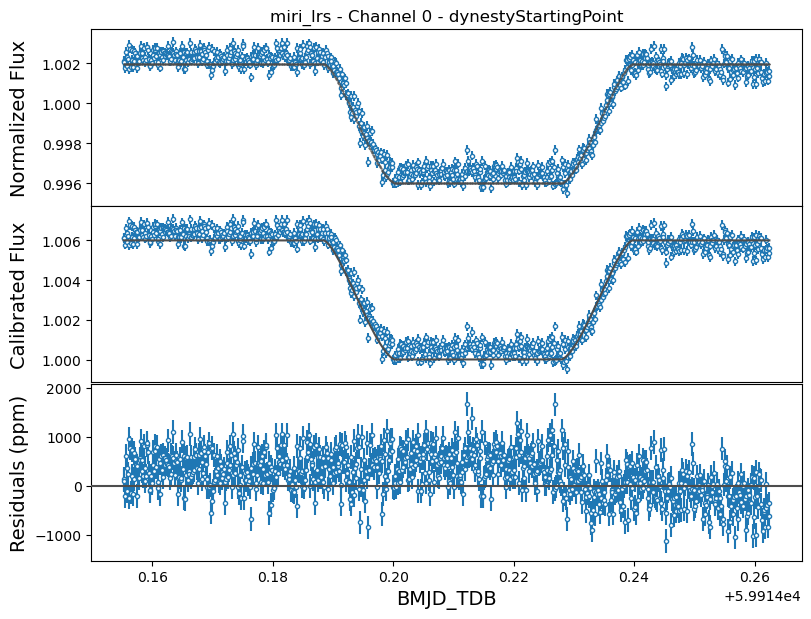

Running dynesty...
Using 45 live points...


1778it [00:13, 132.25it/s, +45 | bound: 117 | nc: 1 | ncall: 55110 | eff(%):  3.311 | loglstar:   -inf < 5835.886 <    inf | logz: 5799.053 +/-  0.855 | dlogz:  0.002 >  0.100]


Summary
nlive: 45
niter: 1778
ncall: 55065
eff(%):  3.311
logz: 5799.053 +/-  0.953

Number of posterior samples is 1823


Finished writing to /home/tbell/Data/JWST/jwebbinar41/miri_lrs/Stage5_white/S5_2025-05-02_miri_lrs_run1/ap5_bg11/S5_dynesty_samples_ch0.h5
Ending lnprob: 5859.585753022099
Reduced Chi-squared: 1.0151815201709866

DYNESTY RESULTS:
fp: 0.0056534578246736 (+3.2292773980618916e-05, -2.7055608985115595e-05)
t0: 55934.29228848981 (+1.0697207471821457e-05, -1.0217234375886619e-05)
c0: 0.9964652377475831 (+1.821457306450114e-05, -1.90976140181931e-05)
c1: -0.0069629212265113925 (+0.0004255389072690607, -0.0005582583414286873)
r0: -0.0002768855512005805 (+0.00010994028397475527, -0.00011169193829922475)
r1: 331.1887605251459 (+108.53171413622016, -160.5652336623185)
ypos: 0.004541874803833281 (+0.0019481504274433984, -0.0017518806479089946)
ywidth: 0.002760671157144944 (+0.0026603031807398876, -0.0021464615891677967)
scatter_mult: 1.6371377023179177 (+0.04169093934459944, -0.034442859800187575); 360.9229873927413 (+9.191174544546877, -7.593264656865756) ppm



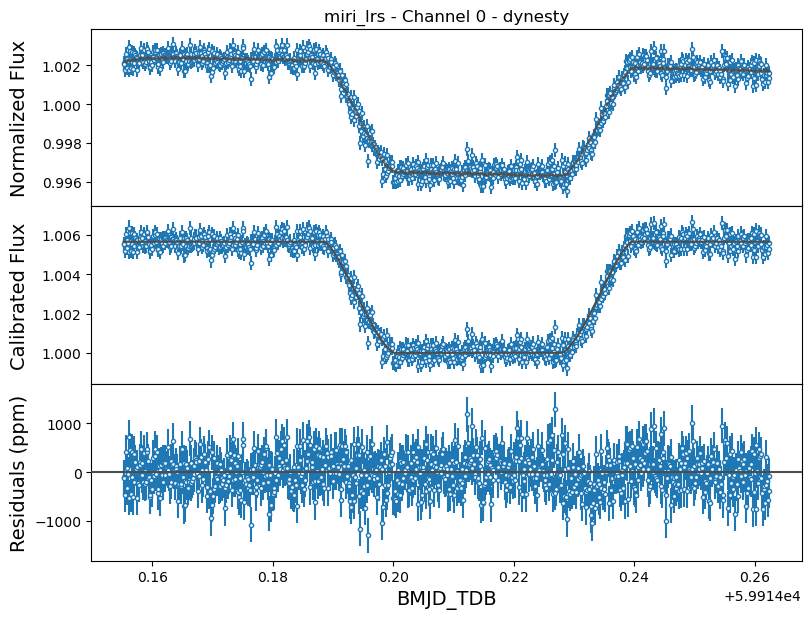

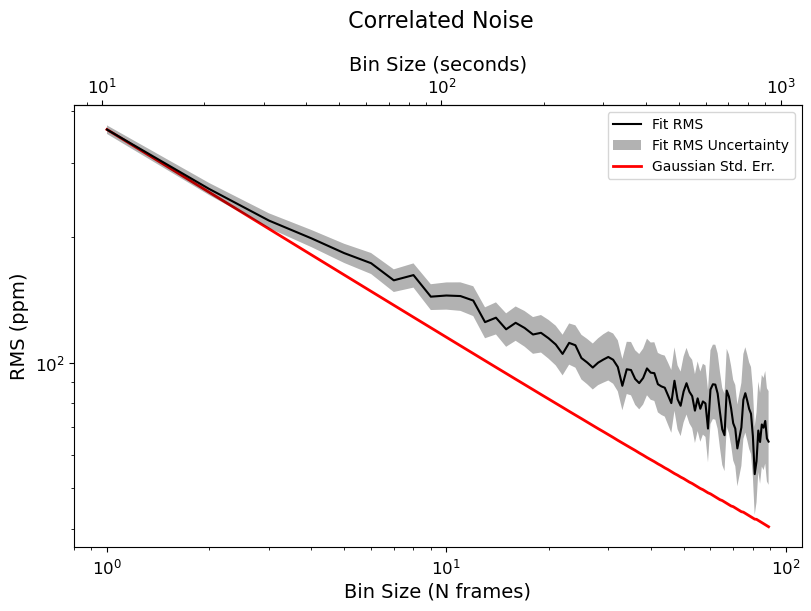

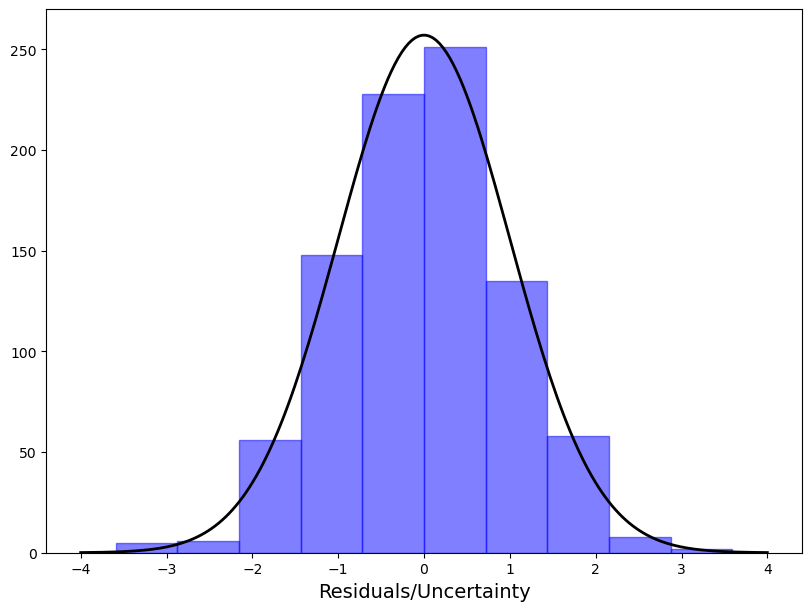

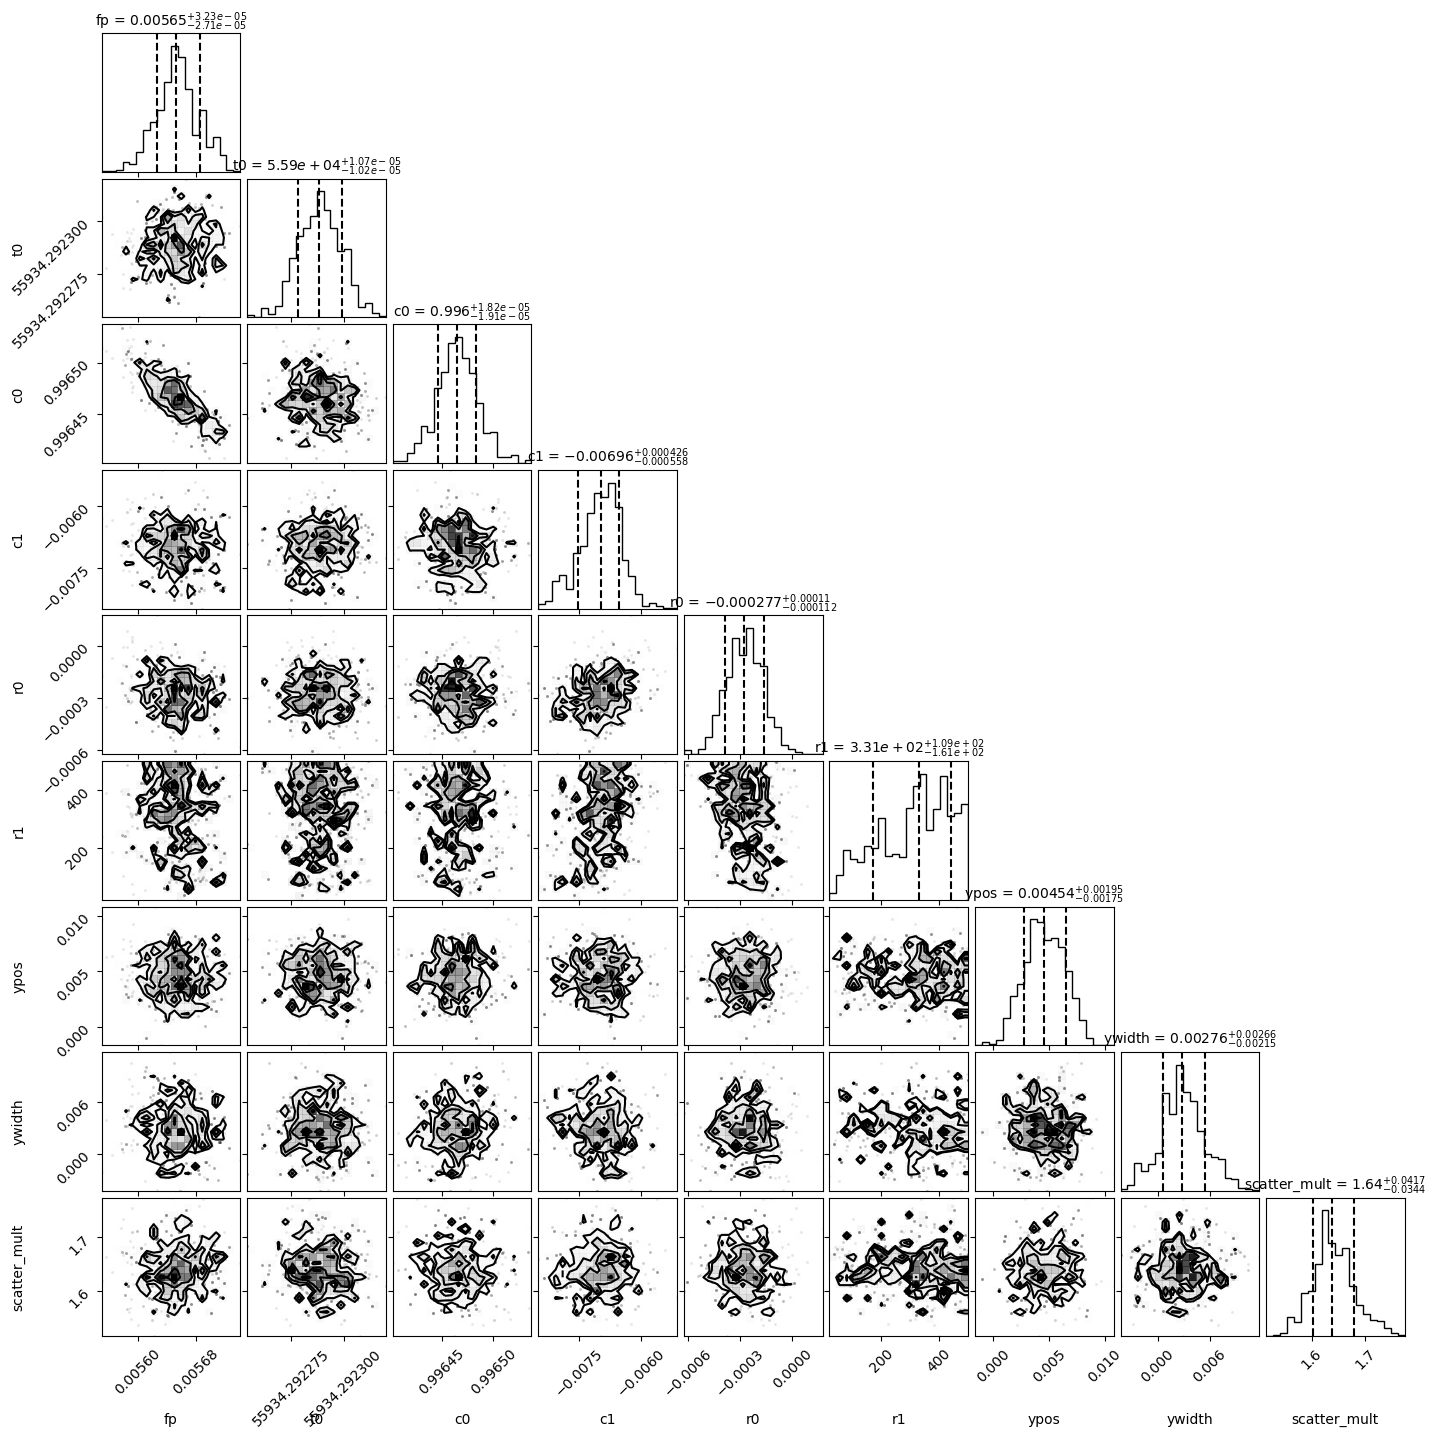

Completed dynesty fit.
-------------------------


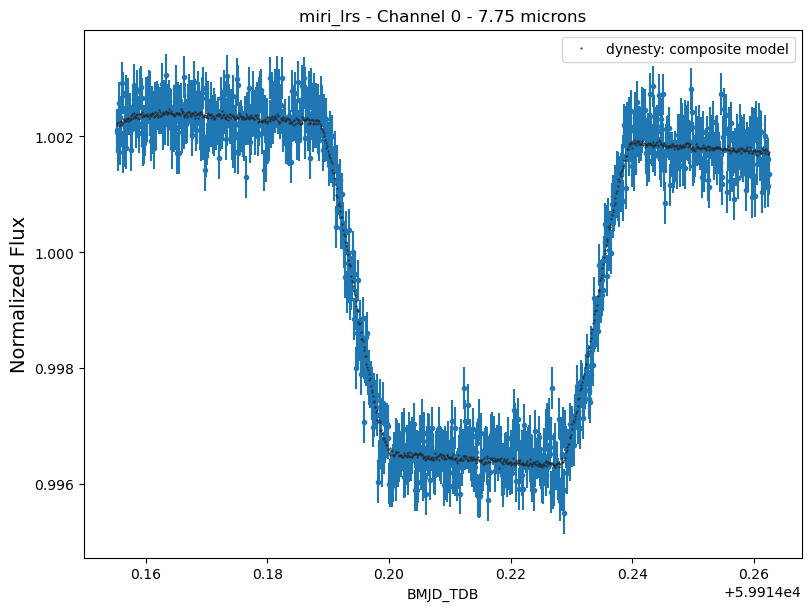

Saving results

Total time (min): 0.39


In [6]:
s5_meta = eureka.S5_lightcurve_fitting.s5_fit.fitlc(eventlabel, ecf_path='./')

<hr style="border:1px solid gray"> </hr>

<img style="float: center;" src="https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_footer.png" alt="stsci_logo" width="200px"/> 